# Q1
**Q1.** Write a code in Python to generate synthetic data to showcase the Employee Performance Dataset where we simulate 1,000 employees with features like age, department, years of experience, performance score, salary, training hours etc.
Visualize the following KPIs using matplotlib and seaborn and gather insights from it:
-	Employee distribution per department
-	Average salary per department
-	Learning investment by department
-	Relationship between training and performance
-	Department-wise WLB health


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

# -----------------------------
# Departments & distributions
# -----------------------------
departments = ['IT', 'HR', 'Finance', 'Sales', 'Operations']
dept_probs = [0.30, 0.15, 0.20, 0.20, 0.15]

department = np.random.choice(departments, size=n, p=dept_probs)

# -----------------------------
# Age (realistic workforce)
# -----------------------------
age = np.clip(np.random.normal(35, 8, n), 21, 60).astype(int)

# -----------------------------
# Experience (correlated with age)
# -----------------------------
experience = np.clip(age - np.random.randint(20, 30, n), 0, None)

# -----------------------------
# Salary (right-skewed + dept impact)
# -----------------------------
base_salary = {
    'IT': 60000,
    'HR': 40000,
    'Finance': 55000,
    'Sales': 50000,
    'Operations': 45000
}

salary = []
for d, exp in zip(department, experience):
    sal = base_salary[d] + exp * np.random.randint(2000, 3500)
    sal += np.random.normal(0, 8000)  # noise
    salary.append(max(25000, sal))

salary = np.array(salary).astype(int)

# -----------------------------
# Training hours (skewed)
# -----------------------------
training_hours = []
for d in department:
    if d in ['IT', 'Finance']:
        training_hours.append(np.random.gamma(5, 6))
    else:
        training_hours.append(np.random.gamma(4, 5))

training_hours = np.clip(training_hours, 5, 120)

# -----------------------------
# Performance score (correlated)
# -----------------------------
performance_score = (
    0.4 * (experience / experience.max()) +
    0.4 * (training_hours / training_hours.max()) +
    np.random.normal(0, 0.1, n)
)

performance_score = np.clip(performance_score * 100, 40, 100)

# -----------------------------
# Work-Life Balance score
# -----------------------------
wlb_base = {
    'IT': 60,
    'HR': 75,
    'Finance': 65,
    'Sales': 62,
    'Operations': 70
}

wlb_score = [
    np.clip(wlb_base[d] + np.random.normal(0, 8), 40, 90)
    for d in department
]

# -----------------------------
# Final Dataset
# -----------------------------
employee_df = pd.DataFrame({
    'Age': age,
    'Department': department,
    'Years_of_Experience': experience,
    'Salary': salary,
    'Training_Hours': training_hours.round(1),
    'Performance_Score': performance_score.round(1),
    'WLB_Score': np.round(wlb_score, 1)
})

employee_df.head()


,Age,Department,Years_of_Experience,Salary,Training_Hours,Performance_Score,WLB_Score
0,36,HR,16,100700,11.1,40.0,87.9
1,24,Operations,0,32707,30.8,40.0,79.7
2,38,Sales,18,116961,34.0,45.4,67.5
3,39,Finance,17,106854,29.7,40.0,65.0
4,39,IT,12,112566,27.0,40.0,64.6


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

employee_df.head(10)

,Age,Department,Years_of_Experience,Salary,Training_Hours,Performance_Score,WLB_Score
0,36,HR,16,100700,11.1,40.0,87.9
1,24,Operations,0,32707,30.8,40.0,79.7
2,38,Sales,18,116961,34.0,45.4,67.5
3,39,Finance,17,106854,29.7,40.0,65.0
4,39,IT,12,112566,27.0,40.0,64.6
5,43,IT,21,108301,49.8,40.0,58.8
6,41,IT,18,90034,43.6,40.0,52.2
7,38,Operations,11,90656,29.8,40.0,77.7
8,34,Finance,14,100034,18.5,40.0,64.6
9,21,Sales,0,50535,24.5,40.0,66.2


In [ ]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Department           1000 non-null   object 
 2   Years_of_Experience  1000 non-null   int64  
 3   Salary               1000 non-null   int64  
 4   Training_Hours       1000 non-null   float64
 5   Performance_Score    1000 non-null   float64
 6   WLB_Score            1000 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.8+ KB


In [ ]:
employee_df.describe()

,Age,Years_of_Experience,Salary,Training_Hours,Performance_Score,WLB_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.419000,11.335000,83314.884000,25.236700,40.495400,65.229500
std,7.632804,7.715199,24275.901969,12.931287,2.548214,9.433845
min,21.000000,0.000000,29108.000000,5.000000,40.000000,40.000000
25%,30.000000,5.000000,66045.000000,16.100000,40.000000,58.300000
50%,35.000000,11.000000,82484.500000,23.000000,40.000000,65.100000
75%,40.000000,17.000000,99690.500000,31.425000,40.000000,71.800000
max,60.000000,40.000000,165240.000000,120.000000,84.900000,90.000000


In [ ]:
employee_df['Performance_Score'].unique()

array([40. , 45.4, 41.3, 41.4, 41.9, 59.1, 42.9, 56.8, 55.8, 48.2, 54.3,
       58.6, 48.4, 44.8, 56.3, 40.4, 47. , 46.6, 42.1, 43.8, 47.3, 54.8,
       41. , 43.7, 50.4, 50. , 44.7, 40.1, 45. , 57.2, 48.5, 43.4, 40.8,
       50.3, 49.2, 46.4, 46.3, 46.5, 84.9, 42.5, 49.1, 43.2, 44.5, 41.1,
       51.1, 47.2, 40.5, 41.5, 42.7, 45.7, 60.8, 48.7, 40.7, 51. , 50.9,
       46.2, 50.2, 41.8, 44. , 42.6])

In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
employee_df.select_dtypes(include=np.number).corr()

,Age,Years_of_Experience,Salary,Training_Hours,Performance_Score,WLB_Score
Age,1.000000,0.934148,0.815026,0.035263,0.286298,0.006155
Years_of_Experience,0.934148,1.000000,0.867961,0.022490,0.309804,0.004205
Salary,0.815026,0.867961,1.000000,0.119265,0.291956,-0.134632
Training_Hours,0.035263,0.022490,0.119265,1.000000,0.271819,-0.129252
Performance_Score,0.286298,0.309804,0.291956,0.271819,1.000000,0.021960
WLB_Score,0.006155,0.004205,-0.134632,-0.129252,0.021960,1.000000


<Axes: xlabel='Department', ylabel='Count'>

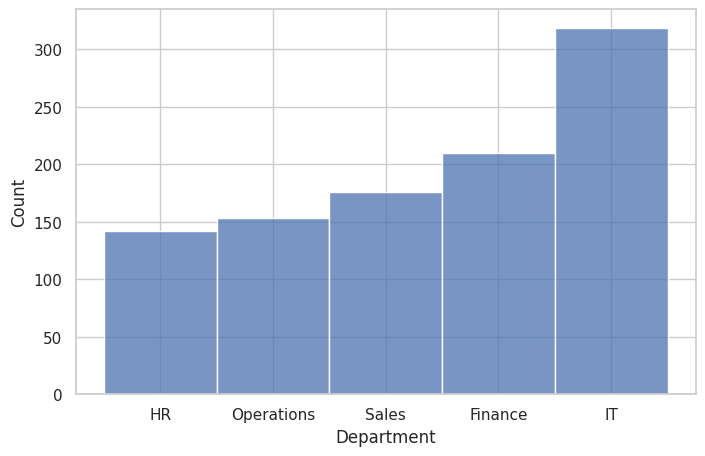

In [ ]:
sns.histplot(employee_df['Department'])

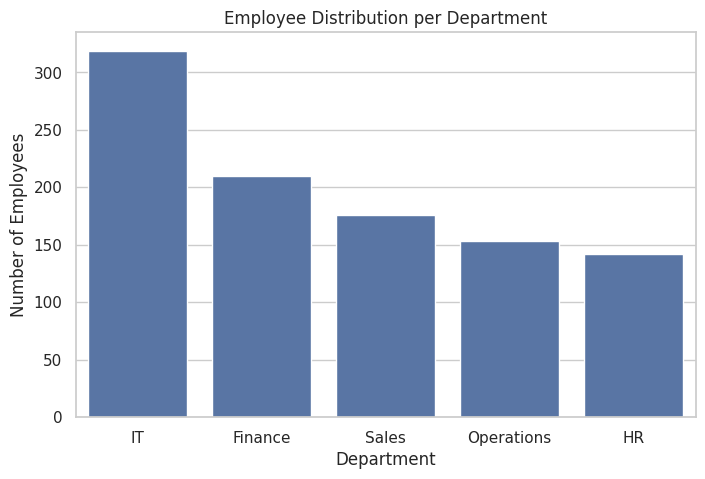

In [ ]:
sns.countplot(
    data=employee_df,
    x='Department',
    order=employee_df['Department'].value_counts().index
)

plt.title("Employee Distribution per Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()


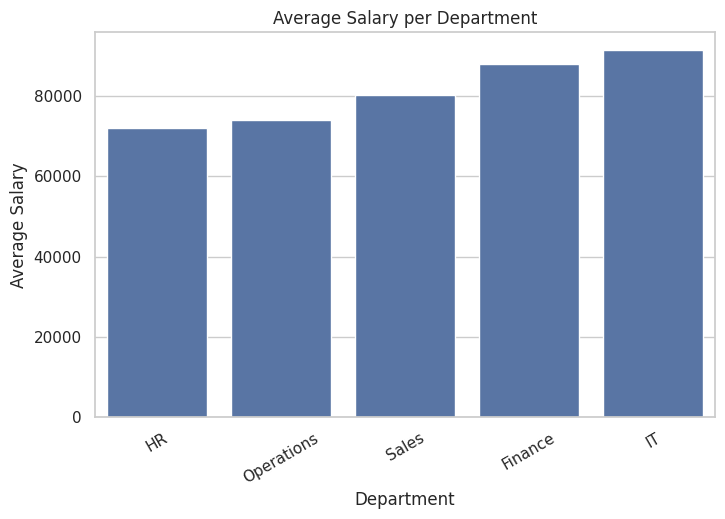

In [ ]:
avg_salary = employee_df.groupby('Department')['Salary'].mean().sort_values()

sns.barplot(
    x=avg_salary.index,
    y=avg_salary.values
)

plt.title("Average Salary per Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.xticks(rotation=30)
plt.show()


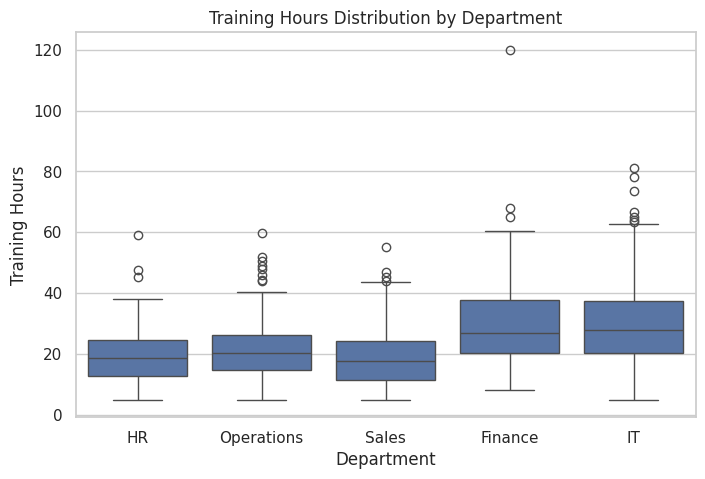

In [ ]:
sns.boxplot(
    data=employee_df,
    x='Department',
    y='Training_Hours'
)

plt.title("Training Hours Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Training Hours")
plt.show()


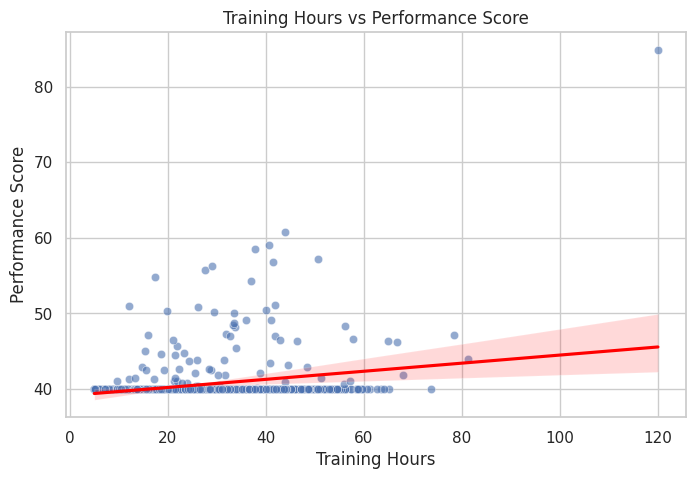

In [ ]:
sns.scatterplot(
    data=employee_df,
    x='Training_Hours',
    y='Performance_Score',
    alpha=0.6
)

sns.regplot(
    data=employee_df,
    x='Training_Hours',
    y='Performance_Score',
    scatter=False,
    color='red'
)

plt.title("Training Hours vs Performance Score")
plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.show()


/tmp/ipython-input-1702342646.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


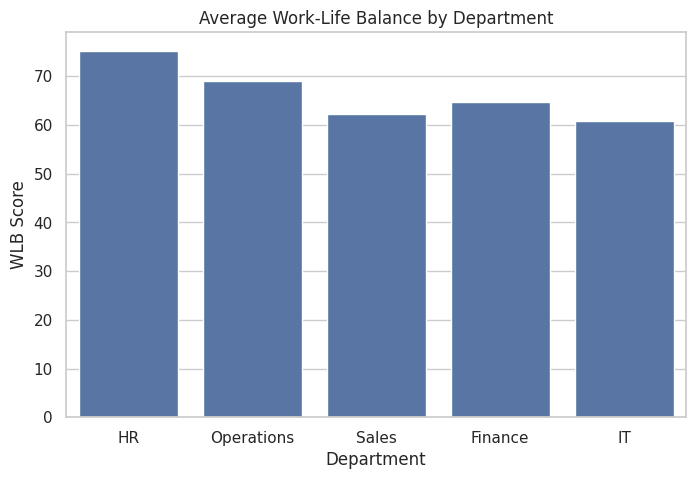

In [ ]:
sns.barplot(
    data=employee_df,
    x='Department',
    y='WLB_Score',
    ci=None
)

plt.title("Average Work-Life Balance by Department")
plt.xlabel("Department")
plt.ylabel("WLB Score")
plt.show()


# Q2

Q2. Using the indian_food.csv dataset provided, visualize the following:
-	Count of vegetarian and non-vegetarian consumers using bar graph
-	Count of unique dishes in this dataset
-	Count of unique flavored dishes in this dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("indian_food.csv")

# Quick look
df.head()


,name,ingredients,diet,prep_time,cook_time,flavor_profile,course,state,region
0,Balu shahi,"Maida flour, yogurt, oil, sugar",vegetarian,45,25,sweet,dessert,West Bengal,East
1,Boondi,"Gram flour, ghee, sugar",vegetarian,80,30,sweet,dessert,Rajasthan,West
2,Gajar ka halwa,"Carrots, milk, sugar, ghee, cashews, raisins",vegetarian,15,60,sweet,dessert,Punjab,North
3,Ghevar,"Flour, ghee, kewra, milk, clarified butter, su...",vegetarian,15,30,sweet,dessert,Rajasthan,West
4,Gulab jamun,"Milk powder, plain flour, baking powder, ghee,...",vegetarian,15,40,sweet,dessert,West Bengal,East


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


In [ ]:
df.describe()

,prep_time,cook_time
count,255.000000,255.000000
mean,31.105882,34.529412
std,72.554409,48.265650
min,-1.000000,-1.000000
25%,10.000000,20.000000
50%,10.000000,30.000000
75%,20.000000,40.000000
max,500.000000,720.000000


In [ ]:
df.isnull().sum()

,0
name,0
ingredients,0
diet,0
prep_time,0
cook_time,0
flavor_profile,0
course,0
state,0
region,1


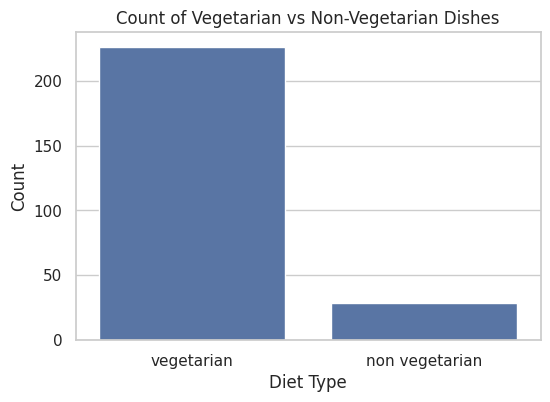

In [ ]:
diet_count = df['diet'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=diet_count.index, y=diet_count.values)

plt.title("Count of Vegetarian vs Non-Vegetarian Dishes")
plt.xlabel("Diet Type")
plt.ylabel("Count")
plt.show()


In [ ]:
unique_dishes = df['name'].nunique()
print("Count of unique dishes:", unique_dishes)


Count of unique dishes: 255


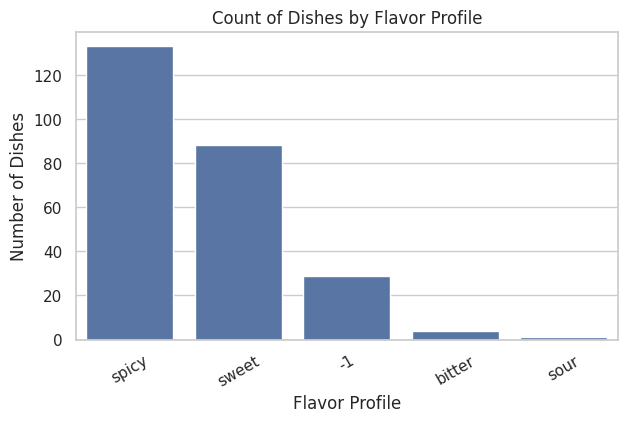

In [ ]:
flavor_count = df['flavor_profile'].value_counts()

plt.figure(figsize=(7,4))
sns.barplot(x=flavor_count.index, y=flavor_count.values)

plt.title("Count of Dishes by Flavor Profile")
plt.xlabel("Flavor Profile")
plt.ylabel("Number of Dishes")
plt.xticks(rotation=30)
plt.show()